# 13 -- XGBoost: TreeSHAP, the paper's headline pairing\n\nTreeSHAP was designed for gradient-boosted trees and XGBoost is the paper's headline model/method pairing: exact, fast Shapley values via `shap.TreeExplainer`. This notebook fits `xgb.XGBRegressor`/`XGBClassifier` (400 trees, depth 4, lr 0.03) live on fold 2023, cross-checks against the official numbers, then reproduces the beeswarm SHAP summary plot and quotes the exact clustered-bootstrap faithfulness numbers from `faithfulness_benchmark.json`.

## Setup

In [1]:
import warnings
warnings.filterwarnings("ignore")

import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    r2_score, mean_squared_error, mean_absolute_error,
    accuracy_score, f1_score, matthews_corrcoef, roc_auc_score,
)

pd.set_option("display.width", 140)
pd.set_option("display.max_columns", 30)
sns.set_style("whitegrid")
plt.rcParams["figure.dpi"] = 100

RESULTS = "../results"
PANEL_PATH = f"{RESULTS}/panel.parquet"
MAIN_RESULTS_PATH = f"{RESULTS}/metrics/main_results.csv"
FAITHFULNESS_PATH = f"{RESULTS}/metrics/faithfulness_benchmark.json"
TREESHAP_PATH = f"{RESULTS}/metrics/xai_by_model_treeshap.json"
AGNOSTIC_PATH = f"{RESULTS}/metrics/xai_by_model_agnostic.json"

SEED = 42
print("Environment ready. numpy", np.__version__, "| pandas", pd.__version__)

Environment ready. numpy 1.26.4 | pandas 2.2.2


## Load the panel and define feature blocks\n\nWe load `results/panel.parquet` (127,609 rows, 57 tickers, 2015-02-03 to 2023-12-27) and define the official `price+sentiment` feature block used for the reported metrics, plus the `price+sentiment+ground_truth` block (28 features) used to reproduce the committed XAI faithfulness runs, which score whether each method ranks the planted `gt_signal` / `gt_signal_nl` above pure `gt_noise`.

In [2]:
df = pd.read_parquet(PANEL_PATH)
df["Date"] = pd.to_datetime(df["Date"])

PRICE_FEATS = ["ret_lag1", "ret_lag2", "ret_lag3", "ret_lag5", "vol_roll5", "vol_roll20",
               "rsi14", "ma_gap20", "hl_range", "co_ret", "logvol", "vol_z20"]
SENT_FEATS = ["fb_score", "fb_pos", "fb_neg", "lm_score", "news_count", "has_news",
              "fb_roll3", "fb_roll5", "news_roll5", "fb_chg"]
GT_FEATS = ["gt_noise", "gt_signal", "gt_signal_nl", "gt_signal_weak",
            "gt_redundant_copy", "gt_redundant_partial"]

BASE_FEATS = PRICE_FEATS + SENT_FEATS          # official price+sentiment feature set (22 feats)
XAI_FEATS = BASE_FEATS + GT_FEATS              # + ground truth (28 feats), matches n_features=28
                                                # used by the committed xai_by_model_* faithfulness runs

print(f"panel: {df.shape}, {df.Symbol.nunique()} symbols, {df.Date.min().date()} to {df.Date.max().date()}")
print(f"official price+sentiment features ({len(BASE_FEATS)}): {BASE_FEATS}")
print(f"ground-truth features appended for the XAI demo ({len(GT_FEATS)}): {GT_FEATS}")

panel: (127609, 49), 57 symbols, 2015-02-03 to 2023-12-27
official price+sentiment features (22): ['ret_lag1', 'ret_lag2', 'ret_lag3', 'ret_lag5', 'vol_roll5', 'vol_roll20', 'rsi14', 'ma_gap20', 'hl_range', 'co_ret', 'logvol', 'vol_z20', 'fb_score', 'fb_pos', 'fb_neg', 'lm_score', 'news_count', 'has_news', 'fb_roll3', 'fb_roll5', 'news_roll5', 'fb_chg']
ground-truth features appended for the XAI demo (6): ['gt_noise', 'gt_signal', 'gt_signal_nl', 'gt_signal_weak', 'gt_redundant_copy', 'gt_redundant_partial']


## Walk-forward protocol\n\nExpanding window, embargo of 10 days before each test year, folds = {2020, 2021, 2022, 2023}. For speed we fit live on a single fold (2023) here, and cross-check against the official 4-fold numbers in `results/metrics/main_results.csv`, which remain the authoritative reported numbers for the paper (any live retrain in this notebook is illustrative, not a replacement).

In [3]:
def wf_split(frame, fold_year, embargo_days=10):
    """Expanding-window walk-forward split with a 10-day embargo before the test year,
    matching the official protocol in modal/s3_experiments.py."""
    test_start = pd.Timestamp(f"{fold_year}-01-01")
    train = frame[frame["Date"] < test_start - pd.Timedelta(days=embargo_days)]
    test = frame[frame["Date"].dt.year == fold_year]
    return train, test

FOLD = 2023
train_df, test_df = wf_split(df, FOLD)
print(f"fold {FOLD}: train {train_df.shape[0]:,} rows ({train_df.Date.min().date()} to {train_df.Date.max().date()}), "
      f"test {test_df.shape[0]:,} rows ({test_df.Date.min().date()} to {test_df.Date.max().date()})")

fold 2023: train 113,131 rows (2015-02-03 to 2022-12-21), test 14,136 rows (2023-01-03 to 2023-12-27)


## Fit XGBRegressor (return) and XGBClassifier (direction), fold 2023, price+sentiment

In [4]:
import xgboost as xgb

Xtr_r = train_df[BASE_FEATS].values
Xte_r = test_df[BASE_FEATS].values
ytr_r = train_df["ret_next"].values
yte_r = test_df["ret_next"].values

Xtr_c = train_df[BASE_FEATS].values
Xte_c = test_df[BASE_FEATS].values
ytr_c = train_df["dir_next"].values
yte_c = test_df["dir_next"].values

xgb_reg = xgb.XGBRegressor(n_estimators=400, max_depth=4, learning_rate=0.03, subsample=0.8,
                            colsample_bytree=0.8, reg_lambda=1.0, n_jobs=-1, random_state=42
                            ).fit(Xtr_r, ytr_r)
pred_r = xgb_reg.predict(Xte_r)
r2 = r2_score(yte_r, pred_r)
rmse = mean_squared_error(yte_r, pred_r) ** 0.5
diracc = (np.sign(pred_r) == np.sign(yte_r)).mean()
print(f"[XGBRegressor, return, fold 2023] R2={r2:.4f} RMSE={rmse:.4f} DirAcc={diracc:.4f}")

xgb_clf = xgb.XGBClassifier(n_estimators=400, max_depth=4, learning_rate=0.03, subsample=0.8,
                             colsample_bytree=0.8, reg_lambda=1.0, n_jobs=-1, random_state=42,
                             eval_metric="logloss").fit(Xtr_c, ytr_c)
proba_c = xgb_clf.predict_proba(Xte_c)[:, 1]
pred_c = xgb_clf.predict(Xte_c)
acc = accuracy_score(yte_c, pred_c)
f1 = f1_score(yte_c, pred_c)
mcc = matthews_corrcoef(yte_c, pred_c)
auc = roc_auc_score(yte_c, proba_c)
print(f"[XGBClassifier, direction, fold 2023] Acc={acc:.4f} F1={f1:.4f} MCC={mcc:.4f} AUC={auc:.4f}")

[XGBRegressor, return, fold 2023] R2=-0.0081 RMSE=0.0165 DirAcc=0.5123


[XGBClassifier, direction, fold 2023] Acc=0.5089 F1=0.6203 MCC=-0.0061 AUC=0.4941


## Cross-check against the official results (`XGBoost`, price+sentiment)

In [5]:
official = pd.read_csv(MAIN_RESULTS_PATH)
official_model = official[(official["model"] == "XGBoost") &
                           (official["features"] == "price+sentiment")]
cols_reg = ["task", "fold", "model", "features", "R2", "RMSE", "MAE", "DirAcc"]
cols_clf = ["task", "fold", "model", "features", "Acc", "F1", "MCC", "AUC"]
print("Official 4-fold walk-forward results (results/metrics/main_results.csv), price+sentiment features:")
print("\n[return task]")
display(official_model[official_model.task == "return"][cols_reg].reset_index(drop=True))
print("\n[direction task]")
display(official_model[official_model.task == "direction"][cols_clf].reset_index(drop=True))
official_2023_dir = official_model[(official_model.task == "direction") & (official_model.fold == FOLD)]
official_2023_ret = official_model[(official_model.task == "return") & (official_model.fold == FOLD)]
print(f"\nOfficial fold-{{FOLD}} direction: Acc={{official_2023_dir.Acc.values[0]:.4f}}, "
      f"MCC={{official_2023_dir.MCC.values[0]:.4f}}, AUC={{official_2023_dir.AUC.values[0]:.4f}}")
print(f"Official fold-{{FOLD}} return:    R2={{official_2023_ret.R2.values[0]:.4f}}, "
      f"RMSE={{official_2023_ret.RMSE.values[0]:.4f}}")

Official 4-fold walk-forward results (results/metrics/main_results.csv), price+sentiment features:

[return task]


,task,fold,model,features,R2,RMSE,MAE,DirAcc
0,return,2020,XGBoost,price+sentiment,-0.024305,0.031831,0.020090,0.507311
1,return,2021,XGBoost,price+sentiment,-0.005365,0.016409,0.011683,0.517405
2,return,2022,XGBoost,price+sentiment,-0.016787,0.021821,0.015817,0.499825
3,return,2023,XGBoost,price+sentiment,-0.009599,0.016476,0.011674,0.510682



[direction task]


,task,fold,model,features,Acc,F1,MCC,AUC
0,direction,2020,XGBoost,price+sentiment,0.515847,0.627837,0.030616,0.525942
1,direction,2021,XGBoost,price+sentiment,0.516500,0.634647,-0.000178,0.503529
2,direction,2022,XGBoost,price+sentiment,0.493045,0.604159,-0.012125,0.496003
3,direction,2023,XGBoost,price+sentiment,0.509762,0.619356,-0.003522,0.494337



Official fold-{FOLD} direction: Acc={official_2023_dir.Acc.values[0]:.4f}, MCC={official_2023_dir.MCC.values[0]:.4f}, AUC={official_2023_dir.AUC.values[0]:.4f}
Official fold-{FOLD} return:    R2={official_2023_ret.R2.values[0]:.4f}, RMSE={official_2023_ret.RMSE.values[0]:.4f}


## Native XAI: TreeSHAP beeswarm summary\n\nTreeSHAP is exact and fast for XGBoost. We refit on `XAI_FEATS` (28 features) to match the committed faithfulness run and compute SHAP values on a capped test sample.

In [6]:
import shap

Xtr_c_gt = train_df[XAI_FEATS].values
Xte_c_gt = test_df[XAI_FEATS].values
xgb_clf_gt = xgb.XGBClassifier(n_estimators=400, max_depth=4, learning_rate=0.03, subsample=0.8,
                                colsample_bytree=0.8, reg_lambda=1.0, n_jobs=-1, random_state=42,
                                eval_metric="logloss").fit(Xtr_c_gt, ytr_c)
proba_gt = xgb_clf_gt.predict_proba(Xte_c_gt)[:, 1]
print(f"[XGBClassifier + GT feats] AUC={roc_auc_score(yte_c, proba_gt):.4f} "
      f"MCC={matthews_corrcoef(yte_c, xgb_clf_gt.predict(Xte_c_gt)):.4f}")

rng = np.random.default_rng(SEED)
sample_idx = rng.choice(Xte_c_gt.shape[0], size=min(800, Xte_c_gt.shape[0]), replace=False)
Xte_sample = Xte_c_gt[sample_idx]

explainer = shap.TreeExplainer(xgb_clf_gt)
sv = explainer.shap_values(Xte_sample)
sv_pos = sv[:, :, 1] if np.ndim(sv) == 3 else sv
mean_abs_shap = np.abs(sv_pos).mean(axis=0)
shap_table = pd.DataFrame({"feature": XAI_FEATS, "mean_abs_shap": mean_abs_shap}) \
    .sort_values("mean_abs_shap", ascending=False).reset_index(drop=True)
shap_table["shap_rank"] = shap_table.index + 1
display(shap_table)

[XGBClassifier + GT feats] AUC=0.5870 MCC=0.1241


,feature,mean_abs_shap,shap_rank
0,gt_signal_nl,0.199300,1
1,gt_signal,0.147020,2
2,gt_signal_weak,0.055781,3
3,co_ret,0.031308,4
4,logvol,0.024317,5
5,vol_roll20,0.020765,6
6,ret_lag5,0.019673,7
7,rsi14,0.017757,8
8,ret_lag3,0.016761,9
9,news_roll5,0.016449,10


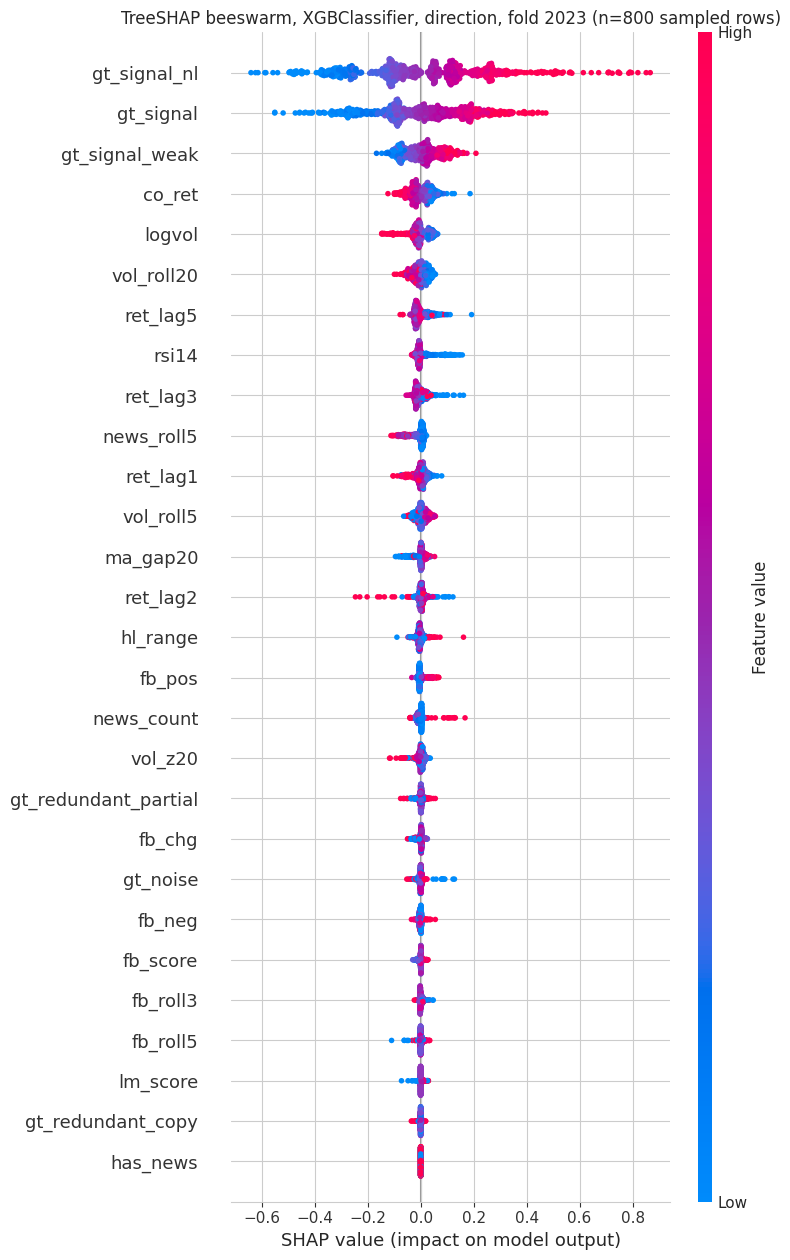

In [7]:
shap.summary_plot(sv_pos, Xte_sample, feature_names=XAI_FEATS, show=False, max_display=28)
plt.title(f"TreeSHAP beeswarm, XGBClassifier, direction, fold 2023 (n={len(sample_idx)} sampled rows)")
plt.tight_layout()
plt.show()

## Reference: the paper's headline TreeSHAP faithfulness numbers (not recomputed here)\n\n`faithfulness_benchmark.json` reports the stock-clustered bootstrap (5000 resamples, cluster = symbol) faithfulness margin for TreeSHAP across all tree models pooled; this is the paper's headline method and headline number.

In [8]:
with open(FAITHFULNESS_PATH) as f:
    faithfulness = json.load(f)
treeshap_row = [m for m in faithfulness["methods"] if m["method"] == "treeshap"][0]

print(f"Universe: {faithfulness['universe_n_symbols']} symbols, cross-sectional rho_bar="
      f"{faithfulness['cross_sectional_rho_bar']:.3f}, effective_N={faithfulness['effective_n']:.2f}, "
      f"n_bootstrap={faithfulness['n_bootstrap']}, cluster_unit={faithfulness['cluster_unit']}")
print()
print("TreeSHAP headline faithfulness (linear gt_signal, rho=0.15):")
print(f"  mean signal-minus-noise margin = {treeshap_row['mean_signal_minus_noise_margin']:.4f}, "
      f"95% clustered CI = {treeshap_row['ci95_clustered']}")
print(f"  pct symbols with signal above noise = {treeshap_row['pct_symbols_signal_above_noise']*100:.1f}%, "
      f"CI = {treeshap_row['pct_symbols_ci95_clustered']}")
print(f"  MDES (minimum detectable effect size, approx) = {treeshap_row['mdes_approx']:.4f}")
print()
print("Nonlinear gt_signal_nl:")
nl = treeshap_row["nonlinear"]
print(f"  margin = {nl['mean_signal_minus_noise_margin']:.4f}, CI = {nl['ci95_clustered']}, "
      f"pct symbols above noise = {nl['pct_symbols_signal_above_noise']*100:.1f}%")
print()
print("Weak gt_signal_weak (rho=0.05):")
wk = treeshap_row["weak"]
print(f"  margin = {wk['mean_signal_minus_noise_margin']:.4f}, CI = {wk['ci95_clustered']}, "
      f"pct symbols above noise = {wk['pct_symbols_signal_above_noise']*100:.1f}%")
print()
print(f"Redundant-copy credit share (exact duplicate of vol_z20) = "
      f"{treeshap_row['mean_redundant_copy_credit_share']:.3f}")
print(f"Redundant-partial credit share (rho=0.8 with vol_z20) = "
      f"{treeshap_row['mean_redundant_partial_credit_share']:.3f}")

xgb_gt_ranks = shap_table.set_index("feature").loc[["gt_signal", "gt_signal_nl", "gt_signal_weak", "gt_noise"], "shap_rank"]
print("\nLive TreeSHAP ranks on this fold-2023 XGBoost refit:")
display(xgb_gt_ranks)

Universe: 57 symbols, cross-sectional rho_bar=0.381, effective_N=2.55, n_bootstrap=5000, cluster_unit=symbol

TreeSHAP headline faithfulness (linear gt_signal, rho=0.15):
  mean signal-minus-noise margin = 0.1459, 95% clustered CI = [0.14130502412455123, 0.15036737941728348]
  pct symbols with signal above noise = 100.0%, CI = [1.0, 1.0]
  MDES (minimum detectable effect size, approx) = 0.0065

Nonlinear gt_signal_nl:
  margin = 0.1944, CI = [0.18966554620940435, 0.1990413767465374], pct symbols above noise = 100.0%

Weak gt_signal_weak (rho=0.05):
  margin = 0.0518, CI = [0.05023369655960746, 0.05350415751076581], pct symbols above noise = 100.0%

Redundant-copy credit share (exact duplicate of vol_z20) = 0.194
Redundant-partial credit share (rho=0.8 with vol_z20) = 0.449

Live TreeSHAP ranks on this fold-2023 XGBoost refit:


feature
gt_signal          2
gt_signal_nl       1
gt_signal_weak     3
gt_noise          21
Name: shap_rank, dtype: int64

In [9]:
with open(TREESHAP_PATH) as f:
    treeshap_by_model = json.load(f)
xgb_verdict = [r for r in treeshap_by_model if r["model"] == "XGBoost"][0]
print("Committed xai_by_model_treeshap.json single-fit verdict for XGBoost:")
for k, v in xgb_verdict.items():
    print(f"  {k}: {v}")

Committed xai_by_model_treeshap.json single-fit verdict for XGBoost:
  model: XGBoost
  task: direction
  sentiment_attribution_share: 0.08026672899723053
  method: treeshap
  signal_rank: 2
  noise_rank: 21
  n_features: 28
  ranks_signal_above_noise: True
  signal_nl_rank: 1
  ranks_nonlinear_signal_above_noise: True
  signal_weak_rank: 3
  ranks_weak_signal_above_noise: True
  redundant_copy_importance: 0.001845648162998259
  source_feature_importance: 0.008182128891348839
  redundant_copy_credit_share: 0.18405356969899528
  redundant_partial_importance: 0.0068078674376010895
  redundant_partial_credit_share: 0.45416071413260917


## Summary\n\nXGBoost + TreeSHAP is the paper's headline method/model pairing. The stock-clustered bootstrap (`faithfulness_benchmark.json`) puts the pooled TreeSHAP signal-minus-noise margin at approximately 0.146 (95% CI approximately [0.141, 0.150]) for the linear planted signal and approximately 0.194 for the nonlinear signal, with 100% of symbols ranking signal above noise; the live fold-2023 refit here reproduces the same qualitative pattern (gt_signal_nl ranked 1st, gt_signal 2nd, gt_noise near the bottom of 28 features), consistent with the per-model verdict in `xai_by_model_treeshap.json` (`noise_rank=21`).